In [8]:
import os
import time
import warnings
import random
import matplotlib.pyplot as plt
# Ensure inline plotting in Jupyter Notebook
%matplotlib inline

# 更改工作目录到项目根目录
os.chdir('../')

import argparse
import torch
import torch.nn as nn
from torch import optim
from torch.utils.tensorboard import SummaryWriter
import numpy as np
from torch.utils.tensorboard import SummaryWriter
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from experiments.exp_long_term_forecasting import Exp_Long_Term_Forecast
from experiments.exp_long_term_forecasting_partial import Exp_Long_Term_Forecast_Partial
from data_provider.data_factory import data_provider
from experiments.exp_basic import Exp_Basic
from utils.tools import EarlyStopping, adjust_learning_rate, visual
from utils.metrics import metric

fix_seed = 2023
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

In [2]:
parser = argparse.ArgumentParser(description='iTransformer')

# basic config
parser.add_argument('--is_training', type=int, required=True, default=1, help='status')
parser.add_argument('--model_id', type=str, required=True, default='test', help='model id')
parser.add_argument('--model', type=str, required=True, default='iTransformer',
                    help='model name, options: [iTransformer, iInformer, iReformer, iFlowformer, iFlashformer]')

# data loader
parser.add_argument('--data', type=str, required=True, default='custom', help='dataset type')
parser.add_argument('--root_path', type=str, default='./data/electricity/', help='root path of the data file')
parser.add_argument('--data_path', type=str, default='electricity.csv', help='data csv file')
parser.add_argument('--features', type=str, default='M',
                    help='forecasting task, options:[M, S, MS]; M:multivariate predict multivariate, S:univariate predict univariate, MS:multivariate predict univariate')
parser.add_argument('--target', type=str, default='OT', help='target feature in S or MS task')
parser.add_argument('--freq', type=str, default='h',
                    help='freq for time features encoding, options:[s:secondly, t:minutely, h:hourly, d:daily, b:business days, w:weekly, m:monthly], you can also use more detailed freq like 15min or 3h')
parser.add_argument('--checkpoints', type=str, default='./checkpoints/', help='location of model checkpoints')

# forecasting task
parser.add_argument('--seq_len', type=int, default=96, help='input sequence length')
parser.add_argument('--label_len', type=int, default=48, help='start token length') # no longer needed in inverted Transformers
parser.add_argument('--pred_len', type=int, default=96, help='prediction sequence length')

# model define
parser.add_argument('--load_path', type=str, default=None, help='the path of the model that you want to load')
parser.add_argument('--enc_in', type=int, default=7, help='encoder input size')
parser.add_argument('--dec_in', type=int, default=7, help='decoder input size')
parser.add_argument('--c_out', type=int, default=7, help='output size') # applicable on arbitrary number of variates in inverted Transformers
parser.add_argument('--d_model', type=int, default=512, help='dimension of model')
parser.add_argument('--n_heads', type=int, default=8, help='num of heads')
parser.add_argument('--e_layers', type=int, default=2, help='num of encoder layers')
parser.add_argument('--d_layers', type=int, default=1, help='num of decoder layers')
parser.add_argument('--d_ff', type=int, default=2048, help='dimension of fcn')
parser.add_argument('--moving_avg', type=int, default=25, help='window size of moving average')
parser.add_argument('--factor', type=int, default=1, help='attn factor')
parser.add_argument('--distil', action='store_false',
                    help='whether to use distilling in encoder, using this argument means not using distilling',
                    default=True)
parser.add_argument('--dropout', type=float, default=0.1, help='dropout')
parser.add_argument('--embed', type=str, default='timeF',
                    help='time features encoding, options:[timeF, fixed, learned]')
parser.add_argument('--activation', type=str, default='gelu', help='activation')
parser.add_argument('--output_attention', action='store_true', help='whether to output attention in ecoder', default=False)
parser.add_argument('--do_predict', action='store_true', help='whether to predict unseen future data', default=False)
parser.add_argument('--no_embedding', action='store_true', help='whether to use embedding', default=False)

# optimization
parser.add_argument('--num_workers', type=int, default=10, help='data loader num workers')
parser.add_argument('--itr', type=int, default=1, help='experiments times')
parser.add_argument('--train_epochs', type=int, default=10, help='train epochs')
parser.add_argument('--batch_size', type=int, default=32, help='batch size of train input data')
parser.add_argument('--patience', type=int, default=3, help='early stopping patience')
parser.add_argument('--learning_rate', type=float, default=0.0001, help='optimizer learning rate')
parser.add_argument('--des', type=str, default='test', help='exp description')
parser.add_argument('--loss', type=str, default='MSE', help='loss function')
parser.add_argument('--lradj', type=str, default='type1', help='adjust learning rate')
parser.add_argument('--use_amp', action='store_true', help='use automatic mixed precision training', default=False)

# GPU
parser.add_argument('--use_gpu', type=bool, default=True, help='use gpu')
parser.add_argument('--gpu', type=int, default=0, help='gpu')
parser.add_argument('--use_multi_gpu', action='store_true', help='use multiple gpus', default=False)
parser.add_argument('--devices', type=str, default='0,1,2,3', help='device ids of multile gpus')

# iTransformer
parser.add_argument('--exp_name', type=str, required=False, default='MTSF',
                    help='experiemnt name, options:[MTSF, partial_train]')
parser.add_argument('--channel_independence', type=bool, default=False, help='whether to use channel_independence mechanism')
parser.add_argument('--inverse', action='store_true', help='inverse output data', default=False)
parser.add_argument('--class_strategy', type=str, default='projection', help='projection/average/cls_token')
parser.add_argument('--target_root_path', type=str, default='./data/electricity/', help='root path of the data file')
parser.add_argument('--target_data_path', type=str, default='electricity.csv', help='data file')
parser.add_argument('--efficient_training', type=bool, default=False, help='whether to use efficient_training (exp_name should be partial train)') # See Figure 8 of our paper for the detail
parser.add_argument('--use_norm', type=int, default=True, help='use norm and denorm')
parser.add_argument('--partial_start_index', type=int, default=0, help='the start index of variates for partial training, '
                                                                        'you can select [partial_start_index, min(enc_in + partial_start_index, N)]')

args_dict = {
    "--is_training": 1,
    "--root_path": "./dataset/electricity/",
    "--data_path": "electricity.csv",
    "--model_id": "ECL_96_96",
    "--model": 'iTransformer',
    "--data": "custom",
    "--features": "M",
    "--seq_len": 96,
    "--pred_len": 96,
    "--e_layers": 2,
    "--enc_in": 321,
    "--dec_in": 321,
    "--c_out": 321,
    "--des": "Exp",
    "--itr": 1,
    "--train_epochs": 20,
    "--patience": 5,
    "--use_multi_gpu": None,
    "--devices": "0,1"
}
# 将字典转换为列表
args_list = []
for key, value in args_dict.items():
    if isinstance(value, bool):
        raise NotImplementedError
        if value:
            args_list.append(key)
            args_list.append('1')
    else:
        args_list.append(key)
        if value is not None:
            args_list.append(str(value))

# 解析参数
args = parser.parse_args(args_list)
args.use_gpu = True if torch.cuda.is_available() and args.use_gpu else False

if args.use_gpu and args.use_multi_gpu:
    args.devices = args.devices.replace(' ', '')
    device_ids = args.devices.split(',')
    args.device_ids = [int(id_) for id_ in device_ids]
    args.gpu = args.device_ids[0]


if args.exp_name == 'partial_train': # See Figure 8 of our paper, for the detail
    Exp = Exp_Long_Term_Forecast_Partial
else: # MTSF: multivariate time series forecasting
    Exp = Exp_Long_Term_Forecast

# 打印解析后的参数
print(args)

exp = Exp(args)  # set experiments

Namespace(is_training=1, model_id='ECL_96_96', model='iTransformer', data='custom', root_path='./dataset/electricity/', data_path='electricity.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=96, load_path=None, enc_in=321, dec_in=321, c_out=321, d_model=512, n_heads=8, e_layers=2, d_layers=1, d_ff=2048, moving_avg=25, factor=1, distil=True, dropout=0.1, embed='timeF', activation='gelu', output_attention=False, do_predict=False, no_embedding=False, num_workers=10, itr=1, train_epochs=20, batch_size=32, patience=5, learning_rate=0.0001, des='Exp', loss='MSE', lradj='type1', use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=True, devices='0,1', exp_name='MTSF', channel_independence=False, inverse=False, class_strategy='projection', target_root_path='./data/electricity/', target_data_path='electricity.csv', efficient_training=False, use_norm=True, partial_start_index=0, device_ids=[0, 1])
Use GPU: cuda:0


In [3]:
train_data, train_loader = exp._get_data(flag='train')

train 18221


In [9]:
def get_output(exp, model1, model2=None, train_loader=train_loader):
    '''从model中获取输出'''
    # Plot the different train data
    for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):
        batch_x = batch_x.float().to(exp.device)
        batch_y = batch_y.float().to(exp.device)
        if 'PEMS' in exp.args.data or 'Solar' in exp.args.data:
            batch_x_mark = None
            batch_y_mark = None
        else:
            batch_x_mark = batch_x_mark.float().to(exp.device)
            batch_y_mark = batch_y_mark.float().to(exp.device)

        # decoder input
        dec_inp = torch.zeros_like(batch_y[:, -exp.args.pred_len:, :]).float()
        dec_inp = torch.cat([batch_y[:, :exp.args.label_len, :], dec_inp], dim=1).float().to(exp.device)

        # encoder - decoder
        if exp.args.output_attention:
            outputs1 = model1(batch_x, batch_x_mark, dec_inp, batch_y_mark)[0]
            if model2 is not None:
                outputs2 = model2(batch_x, batch_x_mark, dec_inp, batch_y_mark)[0]
        else:
            outputs1 = model1(batch_x, batch_x_mark, dec_inp, batch_y_mark)
            if model2 is not None:
                outputs2 = model2(batch_x, batch_x_mark, dec_inp, batch_y_mark)

        f_dim = -1 if exp.args.features == 'MS' else 0
        outputs1 = outputs1[:, -exp.args.pred_len:, f_dim:]
        if model2 is not None:
            outputs2 = outputs2[:, -exp.args.pred_len:, f_dim:]
        batch_y = batch_y[:, -exp.args.pred_len:, f_dim:].to(exp.device)
        if model2 is not None:
            return outputs1, outputs2, batch_y
        else:
            return outputs1, batch_y

def get_model(exp, model_path):
    '''从.pth中获取模型'''
    model = exp.model_dict[exp.args.model].Model(exp.args).float()
    model.to('cuda')
    if exp.args.use_multi_gpu and exp.args.use_gpu:
        model = nn.DataParallel(model, device_ids=exp.args.device_ids)
    model.load_state_dict(torch.load(model_path))
    return model

def get_loss(path):
    '''从tensorboard log中获取loss'''
    # Load the tensorboard log
    event_acc = EventAccumulator(path)
    event_acc.Reload()

    # Extract scalar data
    scalar_data = {}
    for tag in event_acc.Tags()['scalars']:
        scalar_data[tag] = []
        events = event_acc.Scalars(tag)
        for event in events:
            scalar_data[tag].append((event.step, event.value))

    # Convert to numpy arrays
    scalar_data_np = {tag: np.array(values) for tag, values in scalar_data.items()}
    return scalar_data_np


In [ ]:
model1_path = r'/home/liangzida/workspace/iTransformer/outputs/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_emb/10-23-13-06/checkpoints/1729662002.6219716_trainloss0.17_testloss0.16_valloss0.15_.pth'
model2_path = r'/home/liangzida/workspace/iTransformer/outputs/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_noemb/10-23-13-41/checkpoints/1729663329.9458518_trainloss0.17_testloss0.16_valloss0.14_.pth'

model1 = get_model(exp, model1_path)
model2 = get_model(exp, model2_path)

# 获取两个模型的输出
embedding_output, no_embedding_output, target = get_output(exp, model1, model2)

<Figure size 640x480 with 0 Axes>

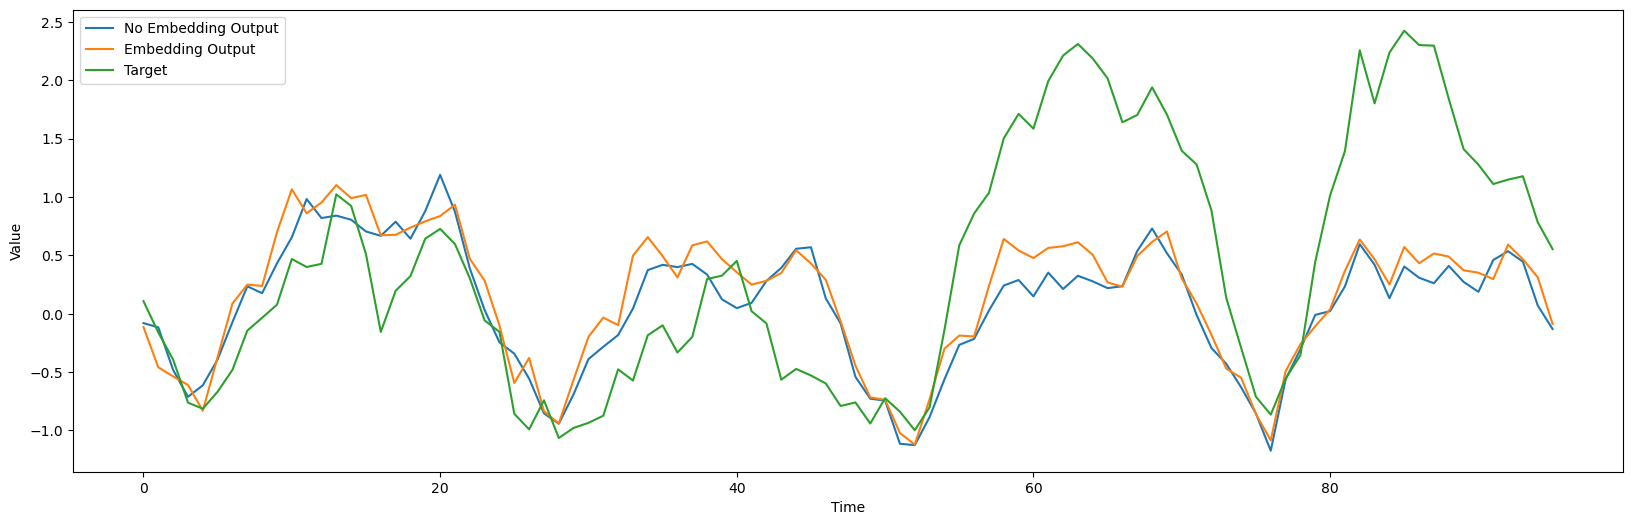

In [5]:
batch = 1
channel = -1
# Ensure inline plotting in Jupyter Notebook
%matplotlib inline
# 在同一张图上画出两个模型的输出以及target
plt.figure()
# 调整图像大小
plt.figure(figsize=(20, 6))
plt.plot(no_embedding_output[batch, :, channel].cpu().detach().numpy().flatten(), label='No Embedding Output')
plt.plot(embedding_output[batch, :, channel].cpu().detach().numpy().flatten(), label='Embedding Output')
plt.plot(target[batch, :, channel].cpu().detach().numpy().flatten(), label='Target')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

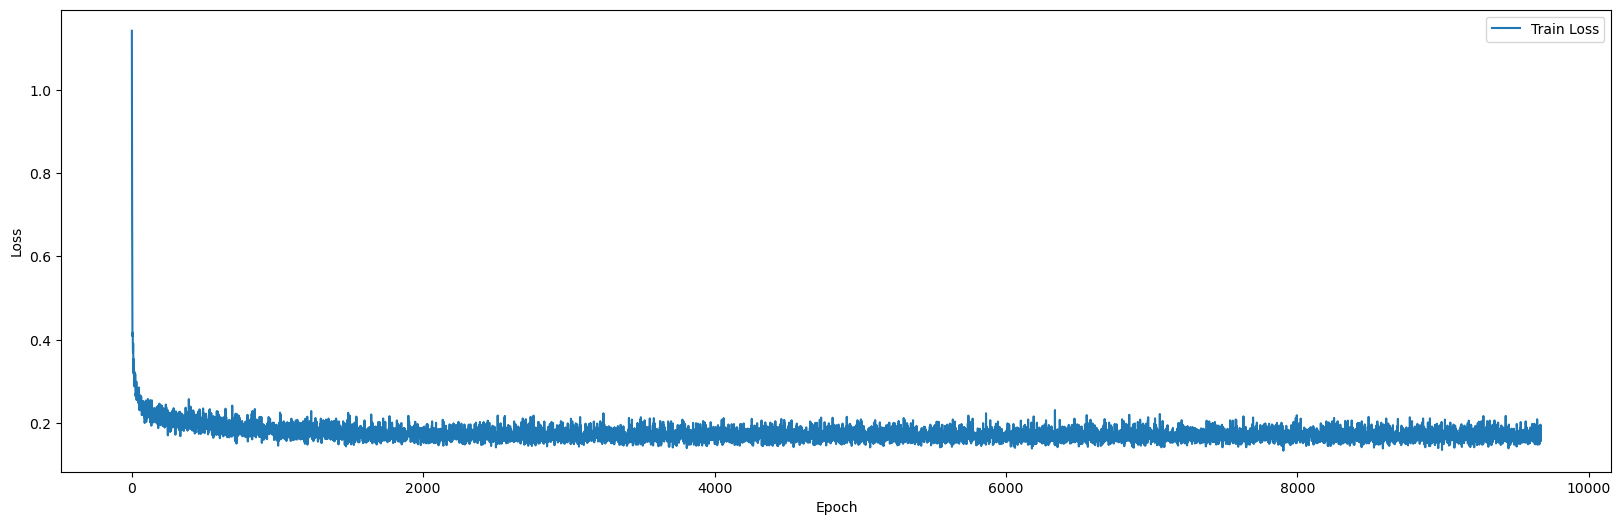

In [22]:
loss_curve_path = r'/home/liangzida/workspace/iTransformer/outputs/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_emb/10-23-13-06/events.out.tfevents.1729660018.front-core-II.37550.0'
loss_curve = get_loss(loss_curve_path)
# 每个epoch有569个batch（iter）
loss_curve = loss_curve['Loss/train'][:loss_curve['Loss/train'].shape[0] // 569 * 569, 1]

# plot the loss curve
plt.figure()
plt.figure(figsize=(20, 6))
plt.plot(loss_curve, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
# 把loss_curve reshape成(569, :)
loss_curve = loss_curve.reshape(-1, 569)

In [24]:
loss_curve.shape

(17, 569)

<Figure size 640x480 with 0 Axes>

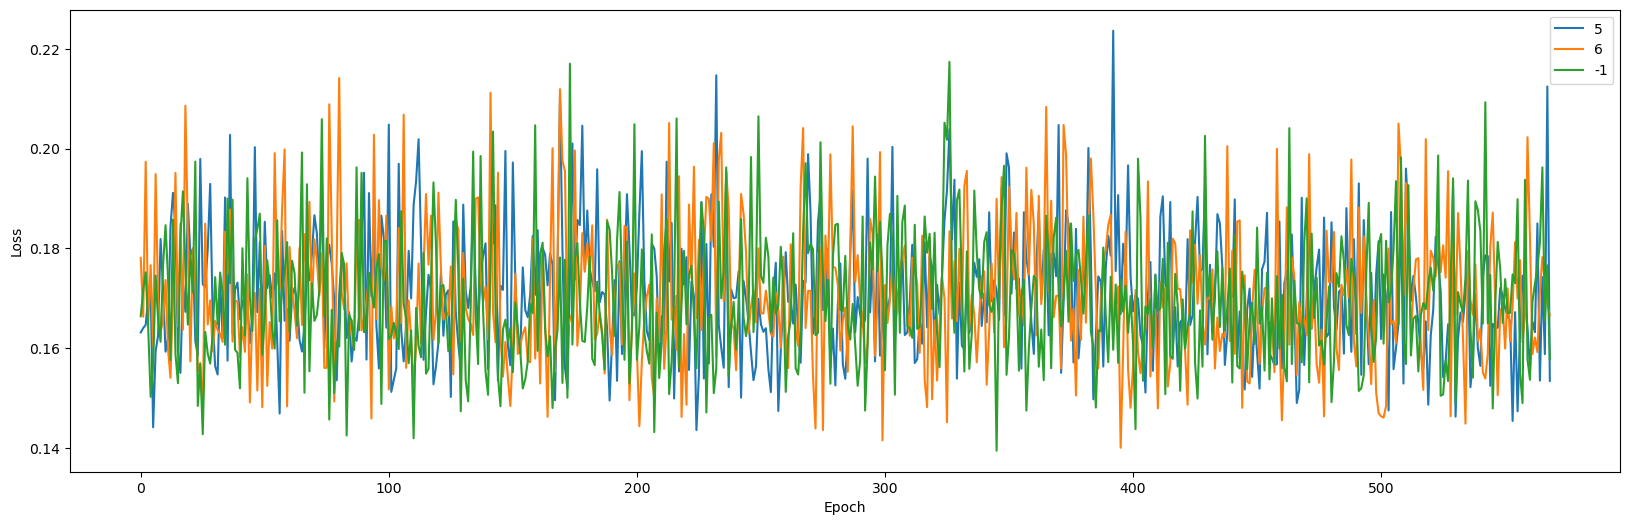

In [28]:

plt.figure()
plt.figure(figsize=(20, 6))
# plt.plot(loss_curve[0], label='0')
plt.plot(loss_curve[5], label='5')
plt.plot(loss_curve[6], label='6')
plt.plot(loss_curve[-1], label='-1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

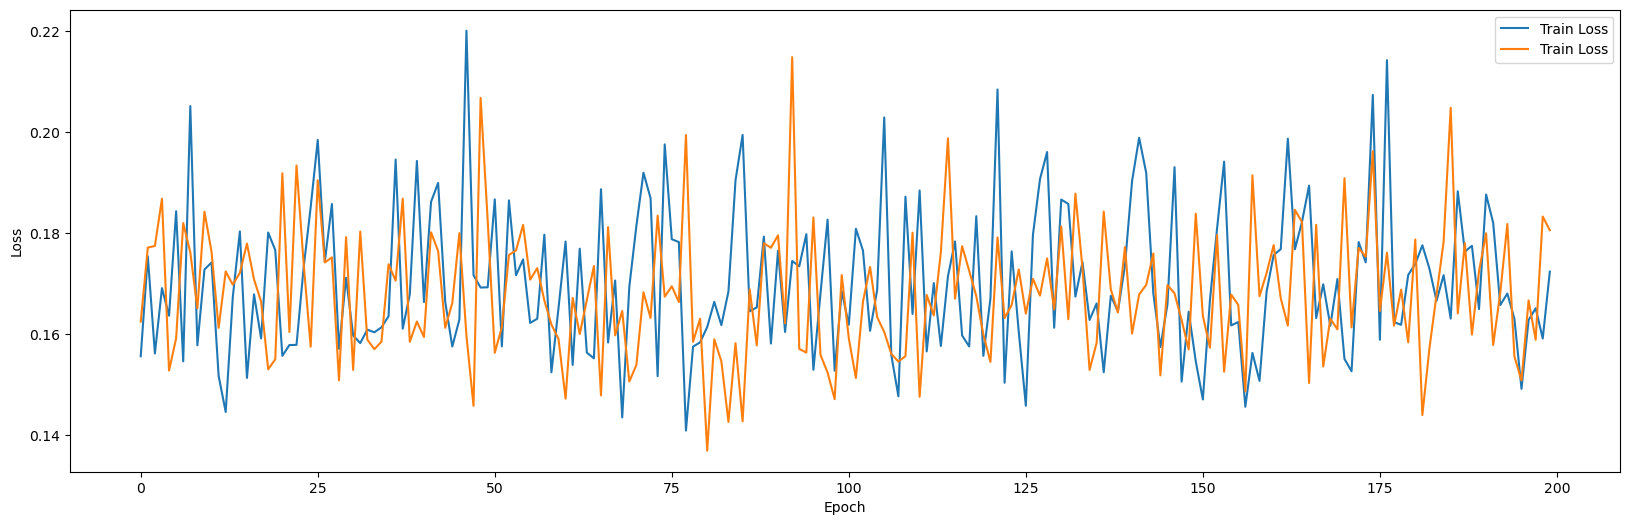

In [32]:
loss_curve_path1 = r'/home/liangzida/workspace/iTransformer/outputs/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_emb/10-23-13-06/events.out.tfevents.1729660018.front-core-II.37550.0'
loss_curve1 = get_loss(loss_curve_path1)
# 每个epoch有569个batch（iter）
loss_curve1 = loss_curve1['Loss/train'][:loss_curve1['Loss/train'].shape[0] // 569 * 569, 1]
loss_curve_path2 = r'/home/liangzida/workspace/iTransformer/outputs/ECL_96_96_iTransformer_custom_M_ft96_sl48_ll96_pl512_dm8_nh2_el1_dl2048_df1_fctimeF_ebTrue_dtExp_projection_noemb/10-23-13-41/events.out.tfevents.1729662116.front-core-II.29590.0'
loss_curve2 = get_loss(loss_curve_path2)
# 每个epoch有569个batch（iter）
loss_curve2 = loss_curve2['Loss/train'][:loss_curve2['Loss/train'].shape[0] // 569 * 569, 1]

# plot the loss curve
plt.figure()
plt.figure(figsize=(20, 6))
plt.plot(loss_curve1[6800:7000], label='Train Loss')
plt.plot(loss_curve2[6800:7000], label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()